In [227]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [125]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

## Первичный осмотр

In [127]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [129]:
df.shape

(891, 12)

In [137]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [149]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## Качество данных - пропуски

In [154]:
print(df.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [156]:
df.isna().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

## Статистика числовых признаков

In [159]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [165]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [161]:
df['SibSp'].describe()

count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

In [163]:
df['Parch'].describe()

count    891.000000
mean       0.381594
std        0.806057
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: Parch, dtype: float64

## Анализ целевой переменной

In [188]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [190]:
df['Survived'].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

## Категориальные признаки - частоты

In [193]:
df['Sex'].value_counts(normalize=True) * 100

Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64

In [197]:
df['Pclass'].value_counts(normalize=True) * 100

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64

In [199]:
df['Embarked'].value_counts(normalize=True) * 100

Embarked
S    72.440945
C    18.897638
Q     8.661417
Name: proportion, dtype: float64

## Выживаемость в разрезе категорий

In [212]:
df.groupby('Sex')['Survived'].mean() * 100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [214]:
df.groupby('Pclass')['Survived'].mean() * 100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [216]:
df.groupby('Embarked')['Survived'].mean() * 100

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64

## Визуализация

<Axes: ylabel='Frequency'>

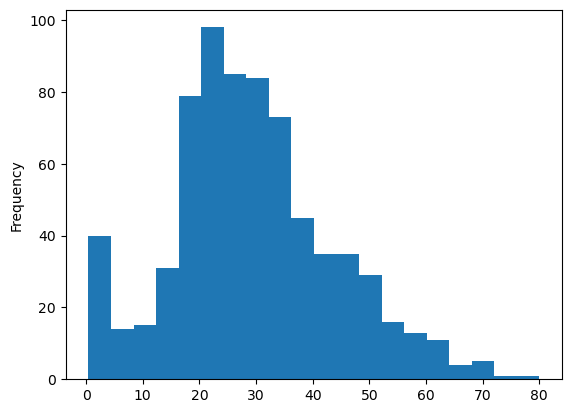

In [223]:
df['Age'].plot(kind='hist', bins=20)

<Axes: ylabel='Frequency'>

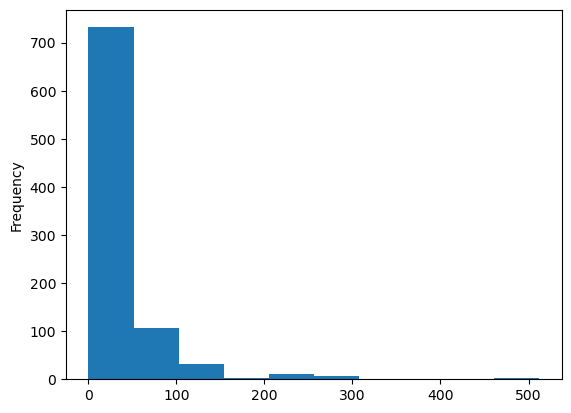

In [225]:
df['Fare'].plot(kind='hist')

In [229]:
df['SurvivedLabel'] = df['Survived'].replace({0: 'Погибшие', 1: 'Выжившие'})

<Axes: xlabel='SurvivedLabel', ylabel='Age'>

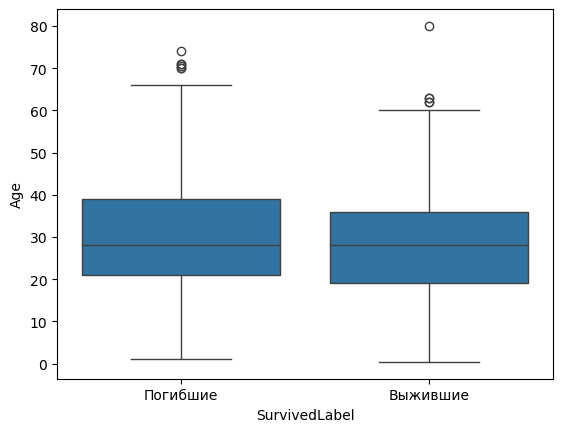

In [233]:
sns.boxplot(data=df, x='SurvivedLabel', y='Age')

<Axes: xlabel='SurvivedLabel', ylabel='Fare'>

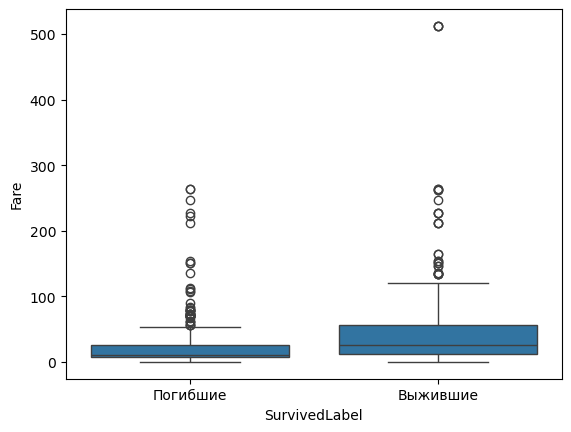

In [235]:
sns.boxplot(data=df, x='SurvivedLabel', y='Fare')

## Корреляции

In [238]:
df_corr = df[['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'Survived']]

In [240]:
df_corr.head(10)

,Age,Fare,SibSp,Parch,Pclass,Survived
0,22.0,7.2500,1,0,3,0
1,38.0,71.2833,1,0,1,1
2,26.0,7.9250,0,0,3,1
3,35.0,53.1000,1,0,1,1
4,35.0,8.0500,0,0,3,0
5,NaN,8.4583,0,0,3,0
6,54.0,51.8625,0,0,1,0
7,2.0,21.0750,3,1,3,0
8,27.0,11.1333,0,2,3,1
9,14.0,30.0708,1,0,2,1


In [244]:
df_corr.corr()

,Age,Fare,SibSp,Parch,Pclass,Survived
Age,1.000000,0.096067,-0.308247,-0.189119,-0.369226,-0.077221
Fare,0.096067,1.000000,0.159651,0.216225,-0.549500,0.257307
SibSp,-0.308247,0.159651,1.000000,0.414838,0.083081,-0.035322
Parch,-0.189119,0.216225,0.414838,1.000000,0.018443,0.081629
Pclass,-0.369226,-0.549500,0.083081,0.018443,1.000000,-0.338481
Survived,-0.077221,0.257307,-0.035322,0.081629,-0.338481,1.000000


<Axes: >

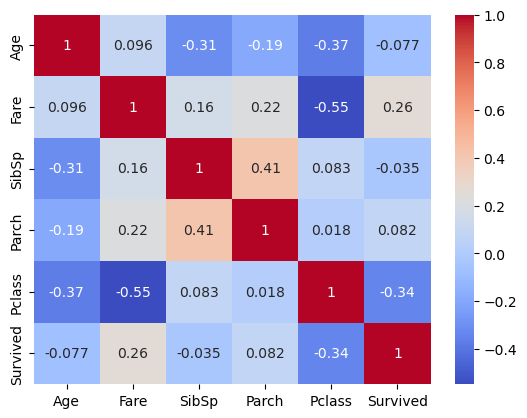

In [246]:
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm')

In [248]:
## Вывод
# Три фактора, влияющие на выживание:
1. Пол (женщины выживали намного чаще).

2. Класс билета (1 класс имел преимущество).

3. Стоимость билета (дороже билет - выше шанс)

# Интуитивные ожидания подтвердились. 
Правило "женщины и дети первыми" работало. Богатые спасались чаще.

# Неожиданные наблюдения:
Женщины 3 класса выживали чаще, чем мужчины 1 класса. 
Пол перевешивал богатство. Пассажиры из порта Шербур выживали чаще - вероятно, среди них было больше пассажиров 1 класса.

SyntaxError: invalid syntax (1509988804.py, line 3)